# EDA - Forecasting Sticker Sales

In this notebook, I will explore the train and test datasets
- look at the data structure
- check missing values
- analyze `num_sold`
- look at trends and seasonality
- compare countries, stores and products

In [20]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.preprocessing import load_data, preprocess_data, get_missing_summary

### Data loading

Load the train and test datasets and take a first look at their size and structure

In [21]:
train, test = load_data(
    "../data/train.csv",
    "../data/test.csv"
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train.head())
display(test.head())

Train shape: (230130, 6)
Test shape: (98550, 5)


,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


,id,date,country,store,product
0,230130,2017-01-01,Canada,Discount Stickers,Holographic Goose
1,230131,2017-01-01,Canada,Discount Stickers,Kaggle
2,230132,2017-01-01,Canada,Discount Stickers,Kaggle Tiers
3,230133,2017-01-01,Canada,Discount Stickers,Kerneler
4,230134,2017-01-01,Canada,Discount Stickers,Kerneler Dark Mode


### Data quality

Check column types, missing values and duplicated rows

In [22]:
train.info()

print("\nmissing values in train:")
display(get_missing_summary(train))

print("missing values in test:")
display(get_missing_summary(test))

print("train duplicates:", train.duplicated().sum())
print("test duplicates:", test.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 230130 entries, 0 to 230129
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id        230130 non-null  int64  
 1   date      230130 non-null  str    
 2   country   230130 non-null  str    
 3   store     230130 non-null  str    
 4   product   230130 non-null  str    
 5   num_sold  221259 non-null  float64
dtypes: float64(1), int64(1), str(4)
memory usage: 10.5 MB

missing values in train:


,missing_count,missing_percent
id,0,0.000000
date,0,0.000000
country,0,0.000000
store,0,0.000000
product,0,0.000000
num_sold,8871,3.854778


missing values in test:


,missing_count,missing_percent
id,0,0.0
date,0,0.0
country,0,0.0
store,0,0.0
product,0,0.0


train duplicates: 0
test duplicates: 0


### Dataset structure

Preprocess the date column and check the time periods and categorical features

In [23]:
train = preprocess_data(train)
test = preprocess_data(test)

print("train period:", train["date"].min(), "-", train["date"].max())
print("test period:", test["date"].min(), "-", test["date"].max())

print("\ncountries:", train["country"].unique())
print("stores:", train["store"].unique())
print("products:", train["product"].unique())

print("\nnumber of countries:", train["country"].nunique())
print("number of stores:", train["store"].nunique())
print("number of products:", train["product"].nunique())

train period: 2010-01-01 00:00:00 - 2016-12-31 00:00:00
test period: 2017-01-01 00:00:00 - 2019-12-31 00:00:00

countries: <StringArray>
['Canada', 'Finland', 'Italy', 'Kenya', 'Norway', 'Singapore']
Length: 6, dtype: str
stores: <StringArray>
['Discount Stickers', 'Premium Sticker Mart', 'Stickers for Less']
Length: 3, dtype: str
products: <StringArray>
['Holographic Goose', 'Kaggle', 'Kaggle Tiers', 'Kerneler',
 'Kerneler Dark Mode']
Length: 5, dtype: str

number of countries: 6
number of stores: 3
number of products: 5


### Target analysis

Look at the main statistics of `num_sold` before analyzing its distribution

In [24]:
train["num_sold"].describe()

count    221259.000000
mean        752.527382
std         690.165445
min           5.000000
25%         219.000000
50%         605.000000
75%        1114.000000
max        5939.000000
Name: num_sold, dtype: float64

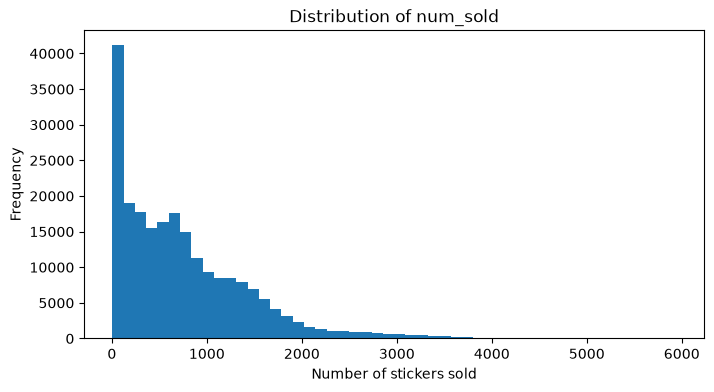

In [25]:
plt.figure(figsize=(8, 4))
plt.hist(train["num_sold"].dropna(), bins=50)

plt.xlabel("Number of stickers sold")
plt.ylabel("Frequency")
plt.title("Distribution of num_sold")
plt.savefig("../results/figures/target_distribution.png", dpi=300)
plt.show()

The target distribution is right-skewed. Most observations have relatively low sales, while high sales values occur less frequently

### Monthly seasonality

Compare average sales by month to check if sales have a seasonal pattern during the year

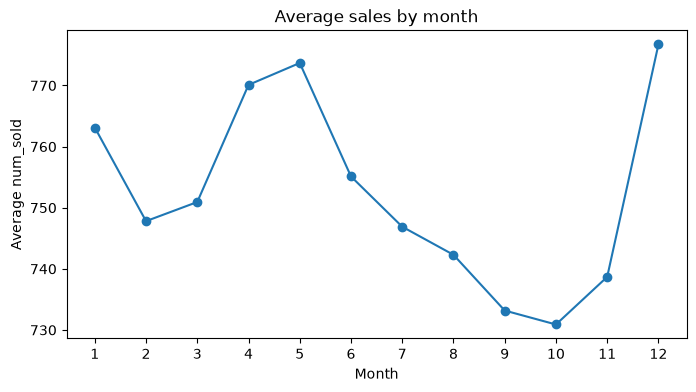

In [26]:
train["month"] = train["date"].dt.month

sales_by_month = train.groupby("month")["num_sold"].mean()

plt.figure(figsize=(8, 4))
plt.plot(sales_by_month.index, sales_by_month.values, marker="o")

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Average num_sold")
plt.title("Average sales by month")
plt.savefig("../results/figures/monthly_seasonality.png", dpi=300)
plt.show()

### Monthly pattern by year

Compare monthly sales for each year to see if the same seasonal pattern repeats over time

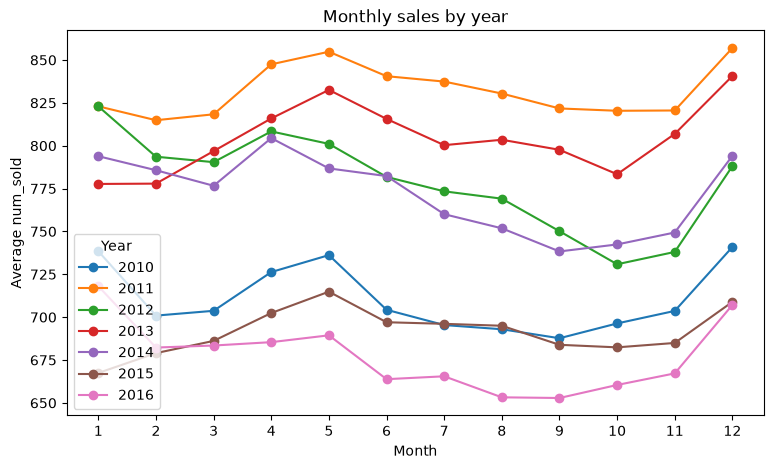

In [27]:
train["year"] = train["date"].dt.year

sales_by_year_month = (
    train.groupby(["year", "month"])["num_sold"]
    .mean()
    .unstack()
)

plt.figure(figsize=(9, 5))

for year in sales_by_year_month.index:
    plt.plot(
        sales_by_year_month.columns,
        sales_by_year_month.loc[year],
        marker="o",
        label=year
    )

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Average num_sold")
plt.title("Monthly sales by year")
plt.legend(title="Year")
plt.savefig("../results/figures/monthly_pattern_by_year.png", dpi=300)
plt.show()

Sales show a seasonal pattern across the year. In many years, sales increase in spring, decrease towards autumn, and rise again in December. The overall sales level also differs between years

### Weekly seasonality

Compare average sales by day of the week to check for a weekly pattern

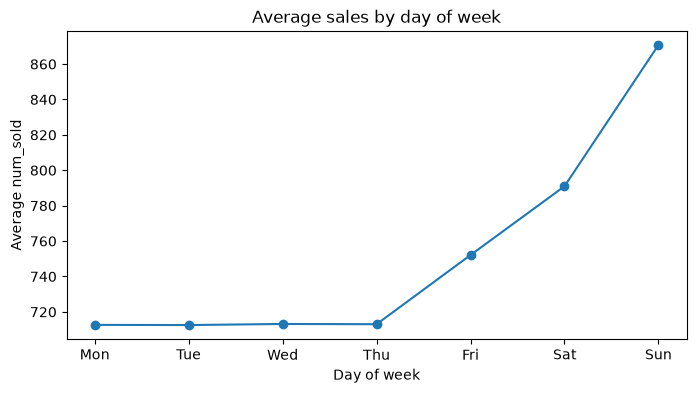

In [28]:
train["day_of_week"] = train["date"].dt.dayofweek

sales_by_weekday = train.groupby("day_of_week")["num_sold"].mean()

weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(8, 4))
plt.plot(sales_by_weekday.index, sales_by_weekday.values, marker="o")

plt.xticks(range(7), weekday_names)
plt.xlabel("Day of week")
plt.ylabel("Average num_sold")
plt.title("Average sales by day of week")
plt.savefig("../results/figures/weekly_seasonality.png", dpi=300)
plt.show()

Sales are almost stable from Monday to Thursday and increase towards the weekend. The highest average sales are observed on Sunday

### Sales by category

Compare average sales across countries, stores and products to see which categories have different sales levels

In [29]:
sales_by_country = train.groupby("country")["num_sold"].mean().sort_values()
sales_by_store = train.groupby("store")["num_sold"].mean().sort_values()
sales_by_product = train.groupby("product")["num_sold"].mean().sort_values()

print("Average sales by country:")
display(sales_by_country)

print("Average sales by store:")
display(sales_by_store)

print("Average sales by product:")
display(sales_by_product)

Average sales by country:


country
Kenya          20.431100
Italy         542.241403
Finland       748.243306
Canada        840.045003
Singapore     863.052379
Norway       1422.560422
Name: num_sold, dtype: float64

Average sales by store:


store
Discount Stickers       427.775887
Stickers for Less       840.046418
Premium Sticker Mart    973.836240
Name: num_sold, dtype: float64

Average sales by product:


product
Holographic Goose      197.484363
Kerneler               556.913102
Kerneler Dark Mode     651.042021
Kaggle Tiers          1018.344110
Kaggle                1232.384587
Name: num_sold, dtype: float64

### Category comparison

Visualize the differences in average sales between countries, stores and products

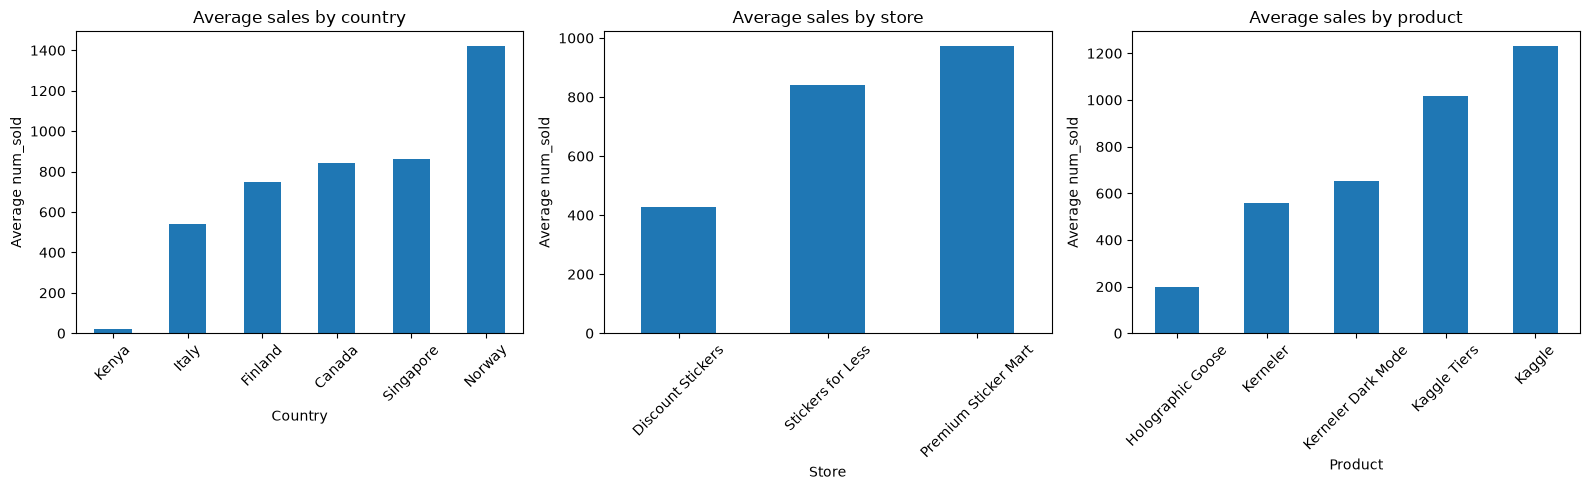

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sales_by_country.plot(kind="bar", ax=axes[0])
axes[0].set_title("Average sales by country")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Average num_sold")

sales_by_store.plot(kind="bar", ax=axes[1])
axes[1].set_title("Average sales by store")
axes[1].set_xlabel("Store")
axes[1].set_ylabel("Average num_sold")

sales_by_product.plot(kind="bar", ax=axes[2])
axes[2].set_title("Average sales by product")
axes[2].set_xlabel("Product")
axes[2].set_ylabel("Average num_sold")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../results/figures/category_comparison.png", dpi=300)
plt.show()

Average sales differ strongly across countries, stores and products. Norway has the highest average sales among countries, Premium Sticker Mart among stores, and Kaggle among products

### Country and product interaction

Compare average product sales across countries to see how these two features interact

In [ ]:
country_product_sales = (
    train.groupby(["country", "product"])["num_sold"]
    .mean()
    .unstack()
)

country_product_sales.round(1)

country_product_sales.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.xlabel("Country")
plt.ylabel("Average num_sold")
plt.title("Average product sales by country")
plt.xticks(rotation=0)
plt.legend(title="Product")

plt.tight_layout()
plt.savefig("../results/figures/country_product_sales.png", dpi=300)
plt.show()

The product pattern is similar across countries: Kaggle has the highest average sales, followed by Kaggle Tiers. However, the overall sales level differs strongly between countries

### Missing target values

Check where the missing `num_sold` values occur and whether they are concentrated in specific categories

In [ ]:
missing_target = train[train["num_sold"].isna()]

print("Missing num_sold:", len(missing_target))
print(
    "Missing percentage:",
    round(len(missing_target) / len(train) * 100, 2),
    "%"
)

print("\nMissing values by country:")
display(missing_target["country"].value_counts())

print("Missing values by product:")
display(missing_target["product"].value_counts())

There are 8,871 missing target values (3.85% of the training data). The missing values are concentrated in Canada and Kenya, and almost all of them belong to Holographic Goose.

In [ ]:
missing_by_year = (
    missing_target
    .groupby(missing_target["date"].dt.year)
    .size()
)

display(missing_by_year)

Missing target values appear in every year of the training period, so they are not limited to a specific time period

### Train and test consistency

Check that train and test contain the same countries, stores and products

In [ ]:
for column in ["country", "store", "product"]:
    train_values = set(train[column].unique())
    test_values = set(test[column].unique())

    print(column)
    print("Only in train:", train_values - test_values)
    print("Only in test:", test_values - train_values)
    print()

Train and test contain the same countries, stores and products. There are no unseen categories in the test set

## EDA conclusions

- `num_sold` is right-skewed, with many lower sales values and fewer very high values.
- Sales show both monthly and weekly seasonality. Weekend sales are higher, with the highest average sales on Sunday.
- Sales levels differ between years.
- Country, store and product are strongly related to the sales level.
- The product pattern is similar across countries, although the overall sales levels differ significantly.
- 3.85% of the target values are missing. These values are mainly associated with Holographic Goose in Canada and Kenya and occur throughout the training period.
- Train and test contain the same categorical values.